In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from setup import train, device, train_test_split_path, accuracy, plot_losses, Image_dataset
X_train_path, X_test_path, X_eval_path, y_train, y_test, y_eval = train_test_split_path()

Usando dispositivo: cuda


### CNN2d
Mfcc y wav2vec2 deberian dar malos resultados porque sus embedding son casi independientes entre si, tiene mas sentido usarlos con conv1d

In [2]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        # (B,1 ,80,3001) → Conv → LeakyReLU → Pool → (B,32,40,1500)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        # (B,32,40,1500) → Conv → LeakyReLU → Pool → (B,64,20,750)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        # (B,64,20,750) → Conv → LeakyReLU → Pool → (B,128,10,375)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        # Global pooling to collapse spatial dims → (B,128,1,1)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.unsqueeze(1) # add channel dimension for Conv2d (B,80,3001) -> (B,1,80,3001)

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        x = self.global_pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        
        return self.fc1(x)

In [3]:
# Definimos hiperparámetros
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

#### Mel

In [4]:
X_train = np.load('../Data/X_train_mel.npy') 
X_test = np.load('../Data/X_test_mel.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-24.3248, -21.0954, -23.4452,  ..., -30.2619, -23.5789, -27.8883],
         [-22.1997, -15.9695, -17.6158,  ..., -30.6667, -25.0086, -25.3555],
         [-22.0932, -18.1459, -19.9255,  ..., -28.9762, -28.1742, -27.1611],
         ...,
         [-44.0200, -39.7173, -41.0933,  ..., -38.3236, -35.2173, -39.8389],
         [-41.5486, -39.7546, -35.8413,  ..., -41.4476, -38.6974, -41.5935],
         [-40.6956, -36.3746, -36.3715,  ..., -40.2328, -41.2249, -43.5400]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (80, 3001),
 'target_length': 10}

In [5]:
# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_mel, val_losses_mel = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 93962 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/20
  Pérdida Entrenamiento: 1.8491
  Pérdida Testeo: 1.6248
  Mejorando
Época 10/20
  Pérdida Entrenamiento: 1.5163
  Pérdida Testeo: 1.3668
  Mejorando
Época 15/20
  Pérdida Entrenamiento: 1.4110
  Pérdida Testeo: 1.2078
  Mejorando
Época 20/20
  Pérdida Entrenamiento: 1.3157
  Pérdida Testeo: 1.1241
  Mejorando
Entrenamiento completado! Tiempo total: 114.90 segundos
--------------------------------------------------
Accuracy del modelo con los datos de testeo: 0.62


In [6]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_mel.pth")

#### Cqt

In [7]:
X_train = np.load('../Data/X_train_cqt.npy') 
X_test = np.load('../Data/X_test_cqt.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-31.1200, -30.9381, -31.0292,  ..., -41.3613, -39.6287, -38.5573],
         [-30.0745, -29.4315, -29.0274,  ..., -32.1641, -32.5271, -33.3078],
         [-33.6152, -32.0733, -31.1597,  ..., -34.5098, -33.3413, -32.3286],
         ...,
         [-36.0252, -36.3203, -43.3733,  ..., -35.3288, -41.8223, -42.4720],
         [-37.7138, -41.6761, -40.3232,  ..., -48.3111, -48.3366, -40.7222],
         [-40.7524, -43.9236, -38.7732,  ..., -47.9594, -52.0674, -50.3824]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (84, 1290),
 'target_length': 10}

In [8]:
# Inicializa el modelo 
model = CNN1().to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 16
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_cqt, val_losses_cqt = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 93962 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/20
  Pérdida Entrenamiento: 2.0302
  Pérdida Testeo: 1.8911
  Empeorando
Época 10/20
  Pérdida Entrenamiento: 1.7619
  Pérdida Testeo: 1.5648
  Mejorando
Época 15/20
  Pérdida Entrenamiento: 1.6862
  Pérdida Testeo: 1.5372
  Empeorando
Época 20/20
  Pérdida Entrenamiento: 1.6092
  Pérdida Testeo: 1.3668
  Mejorando
Entrenamiento completado! Tiempo total: 55.44 segundos
--------------------------------------------------
Accuracy del modelo con los datos de testeo: 0.51


In [9]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_cqt.pth")

#### Summary plot

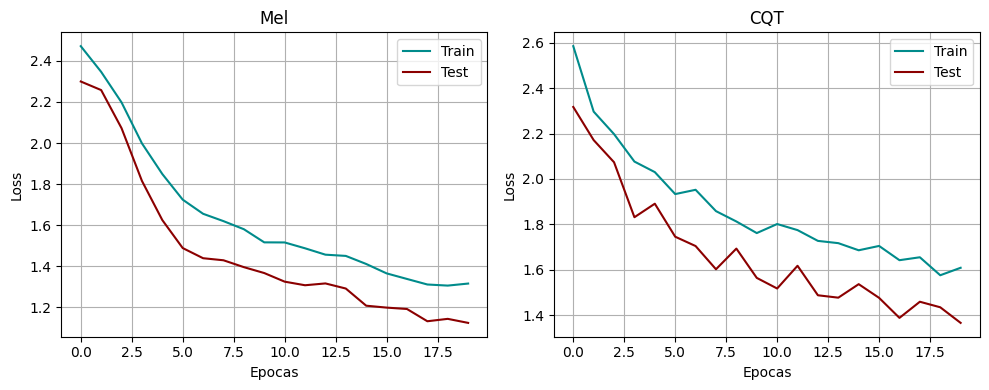

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_losses(train_losses_mel, val_losses_mel, axes[0], title='Mel')
plot_losses(train_losses_cqt, val_losses_cqt, axes[1], title='CQT')
#for ax in axes:
#    ax.set_ylim(-0.1, 2.5)
plt.tight_layout()
plt.show()

Aumentar las epocas de entrenamientos

Accuracy de `0.62` y `0.51` respectivamente 

### CNN1d
Para wav2vec2 y mfcc

In [11]:
class CNN2(nn.Module):
    def __init__(self, feature_len):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=feature_len, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # dim x -> (B,80,3001) caso mel

        x = F.leaky_relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)

        x = F.leaky_relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)
        
        x = F.leaky_relu(self.conv3(x))
        x = F.max_pool1d(x, kernel_size=3, stride=3)
        
        x = self.global_pool(x)

        x = x.view(x.size(0), -1) # -> (B, features_len*4)
        x = F.leaky_relu(x)
        x = self.dropout(x)

        x = self.fc1(x)
        x = F.leaky_relu(x)
        x = self.dropout(x)
        
        return self.fc2(x)

In [12]:
# Definimos hiperparámetros
NUM_EPOCHS = 100
LEARNING_RATE = 0.0001

#### Mel

In [13]:
X_train = np.load('../Data/X_train_mel.npy') 
X_test = np.load('../Data/X_test_mel.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-24.3248, -21.0954, -23.4452,  ..., -30.2619, -23.5789, -27.8883],
         [-22.1997, -15.9695, -17.6158,  ..., -30.6667, -25.0086, -25.3555],
         [-22.0932, -18.1459, -19.9255,  ..., -28.9762, -28.1742, -27.1611],
         ...,
         [-44.0200, -39.7173, -41.0933,  ..., -38.3236, -35.2173, -39.8389],
         [-41.5486, -39.7546, -35.8413,  ..., -41.4476, -38.6974, -41.5935],
         [-40.6956, -36.3746, -36.3715,  ..., -40.2328, -41.2249, -43.5400]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (80, 3001),
 'target_length': 10}

In [14]:
FEATURE_LEN = train_dataset[1]['input_length'][0]

# Inicializa el modelo 
model = CNN2(feature_len=FEATURE_LEN).to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 8
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_mel, val_losses_mel = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 590090 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/100
  Pérdida Entrenamiento: 1.9111
  Pérdida Testeo: 1.7608
  Mejorando
Época 10/100
  Pérdida Entrenamiento: 1.7545
  Pérdida Testeo: 1.6424
  Mejorando
Época 15/100
  Pérdida Entrenamiento: 1.6629
  Pérdida Testeo: 1.5843
  Empeorando
Época 20/100
  Pérdida Entrenamiento: 1.5683
  Pérdida Testeo: 1.5758
  Empeorando
Época 25/100
  Pérdida Entrenamiento: 1.4869
  Pérdida Testeo: 1.4172
  Mejorando
Época 30/100
  Pérdida Entrenamiento: 1.4249
  Pérdida Testeo: 1.3144
  Mejorando
Época 35/100
  Pérdida Entrenamiento: 1.3522
  Pérdida Testeo: 1.2723
  Mejorando
Época 40/100
  Pérdida Entrenamiento: 1.3190
  Pérdida Testeo: 1.2164
  Mejorando
Época 45/100
  Pérdida Entrenamiento: 1.2230
  Pérdida Testeo: 1.2465
  Empeorando
Época 50/100
  Pérdida Entrenamiento: 1.1646
  Pérdida Testeo: 1.1912
  Empeorando
Época 55/100
  Pérdida Entrenamiento: 1.1172
  Pérdida Testeo: 

In [15]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_mel.pth")

#### Mfcc

In [16]:
X_train = np.load('../Data/X_train_mfcc.npy') 
X_test = np.load('../Data/X_test_mfcc.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[ 0.4008,  2.0022,  0.7769,  ..., -0.6358, -0.7985, -1.2709],
         [-0.1132, -0.6555, -0.1558,  ..., -0.5243, -0.3029, -1.2071],
         [ 0.1937, -0.5440,  0.7011,  ...,  0.8279,  0.8248,  0.3340],
         ...,
         [-0.0959, -0.0959, -0.0959,  ...,  0.7572,  0.7572,  0.7572],
         [-0.1486, -0.1486, -0.1486,  ...,  0.9286,  0.9286,  0.9286],
         [-0.5563, -0.5563, -0.5563,  ..., -0.0409, -0.0409, -0.0409]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (60, 1288),
 'target_length': 10}

In [17]:
FEATURE_LEN = train_dataset[1]['input_length'][0]

# Inicializa el modelo 
model = CNN2(feature_len=FEATURE_LEN).to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 16
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_mfcc, val_losses_mfcc = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 582410 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/100
  Pérdida Entrenamiento: 2.3051
  Pérdida Testeo: 2.2990
  Mejorando
Época 10/100
  Pérdida Entrenamiento: 2.2713
  Pérdida Testeo: 2.2566
  Mejorando
Época 15/100
  Pérdida Entrenamiento: 2.0423
  Pérdida Testeo: 1.9587
  Mejorando
Época 20/100
  Pérdida Entrenamiento: 1.8650
  Pérdida Testeo: 1.7455
  Mejorando
Época 25/100
  Pérdida Entrenamiento: 1.7079
  Pérdida Testeo: 1.5977
  Mejorando
Época 30/100
  Pérdida Entrenamiento: 1.5523
  Pérdida Testeo: 1.4547
  Mejorando
Época 35/100
  Pérdida Entrenamiento: 1.4872
  Pérdida Testeo: 1.3571
  Mejorando
Época 40/100
  Pérdida Entrenamiento: 1.2911
  Pérdida Testeo: 1.2451
  Mejorando
Época 45/100
  Pérdida Entrenamiento: 1.2221
  Pérdida Testeo: 1.1796
  Mejorando
Época 50/100
  Pérdida Entrenamiento: 1.1313
  Pérdida Testeo: 1.1307
  Mejorando
Época 55/100
  Pérdida Entrenamiento: 1.0593
  Pérdida Testeo: 1.12

In [ ]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_mfcc.pth")

#### Cqt

In [19]:
X_train = np.load('../Data/X_train_cqt.npy') 
X_test = np.load('../Data/X_test_cqt.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-31.1200, -30.9381, -31.0292,  ..., -41.3613, -39.6287, -38.5573],
         [-30.0745, -29.4315, -29.0274,  ..., -32.1641, -32.5271, -33.3078],
         [-33.6152, -32.0733, -31.1597,  ..., -34.5098, -33.3413, -32.3286],
         ...,
         [-36.0252, -36.3203, -43.3733,  ..., -35.3288, -41.8223, -42.4720],
         [-37.7138, -41.6761, -40.3232,  ..., -48.3111, -48.3366, -40.7222],
         [-40.7524, -43.9236, -38.7732,  ..., -47.9594, -52.0674, -50.3824]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (84, 1290),
 'target_length': 10}

In [20]:
FEATURE_LEN = train_dataset[1]['input_length'][0]

# Inicializa el modelo 
model = CNN2(feature_len=FEATURE_LEN).to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 16
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_cqt, val_losses_cqt = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 591626 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/100
  Pérdida Entrenamiento: 2.0740
  Pérdida Testeo: 1.9576
  Mejorando
Época 10/100
  Pérdida Entrenamiento: 1.8597
  Pérdida Testeo: 1.7345
  Mejorando
Época 15/100
  Pérdida Entrenamiento: 1.7249
  Pérdida Testeo: 1.5433
  Mejorando
Época 20/100
  Pérdida Entrenamiento: 1.5824
  Pérdida Testeo: 1.3978
  Mejorando
Época 25/100
  Pérdida Entrenamiento: 1.4828
  Pérdida Testeo: 1.3244
  Mejorando
Época 30/100
  Pérdida Entrenamiento: 1.3348
  Pérdida Testeo: 1.2957
  Empeorando
Época 35/100
  Pérdida Entrenamiento: 1.2989
  Pérdida Testeo: 1.1459
  Mejorando
Época 40/100
  Pérdida Entrenamiento: 1.2497
  Pérdida Testeo: 1.1152
  Mejorando
Época 45/100
  Pérdida Entrenamiento: 1.1861
  Pérdida Testeo: 1.0938
  Mejorando
Época 50/100
  Pérdida Entrenamiento: 1.0805
  Pérdida Testeo: 1.0418
  Mejorando
Época 55/100
  Pérdida Entrenamiento: 1.0396
  Pérdida Testeo: 1.0

In [ ]:
#torch.save(model.state_dict(), "../Models/cnn_modelo1_cqt.pth")

#### Wav2Vec2

In [22]:
X_train = np.load('../Data/X_train_wav2vec2.npy') 
X_test = np.load('../Data/X_test_wav2vec2.npy') 

print(f"Entrenamiento: {len(X_train)} pares")
print(f"Testeo: {len(X_test)} pares")

train_dataset = Image_dataset(X_train, y_train)
test_dataset = Image_dataset(X_test, y_test)
train_dataset[1]

Entrenamiento: 719 pares
Testeo: 180 pares


{'input': tensor([[-0.2477,  0.1738,  0.1289,  ..., -0.0053,  0.0223,  0.9387],
         [-0.1929,  0.3022,  0.1558,  ..., -0.0471,  0.1158,  1.3188],
         [-0.2169,  0.3275,  0.0660,  ...,  0.0647,  0.1160,  1.3544],
         ...,
         [ 0.0029,  0.1278, -0.3668,  ..., -0.2185, -0.1968,  0.9453],
         [-0.0382,  0.1218, -0.3236,  ..., -0.1585, -0.1787,  0.9811],
         [ 0.0632, -0.0108, -0.1264,  ..., -0.2354, -0.2857,  0.0577]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], device='cuda:0'),
 'input_length': (1496, 768),
 'target_length': 10}

In [23]:
FEATURE_LEN = train_dataset[1]['input_length'][0]

# Inicializa el modelo 
model = CNN2(feature_len=FEATURE_LEN).to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(f"Modelo creado con {sum(p.numel() for p in model.parameters())} parámetros")

#### Entrenamiento del modelo #####
BATCH_SIZE = 4
# DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

train_losses_wav2vec2, val_losses_wav2vec2 = train(model, train_dataloader, val_dataloader, optimizer, criterion, NUM_EPOCHS)
accur = accuracy(model, test_dataset)
print("-" * 50)
print(f"Accuracy del modelo con los datos de testeo: {accur:.2f}")

Modelo creado con 1133834 parámetros
Iniciando entrenamiento...
--------------------------------------------------
Época 5/100
  Pérdida Entrenamiento: 2.2418
  Pérdida Testeo: 2.2718
  Mejorando
Época 10/100
  Pérdida Entrenamiento: 1.7793
  Pérdida Testeo: 2.1072
  Mejorando
Época 15/100
  Pérdida Entrenamiento: 1.5237
  Pérdida Testeo: 2.4225
  Empeorando
Época 20/100
  Pérdida Entrenamiento: 1.3414
  Pérdida Testeo: 2.7024
  Empeorando
Época 25/100
  Pérdida Entrenamiento: 1.0952
  Pérdida Testeo: 2.7772
  Empeorando
Época 30/100
  Pérdida Entrenamiento: 0.7104
  Pérdida Testeo: 3.8619
  Empeorando
Época 35/100
  Pérdida Entrenamiento: 0.4707
  Pérdida Testeo: 4.8724
  Empeorando
Época 40/100
  Pérdida Entrenamiento: 0.3691
  Pérdida Testeo: 6.3951
  Empeorando
Época 45/100
  Pérdida Entrenamiento: 0.3221
  Pérdida Testeo: 8.6384
  Empeorando
Época 50/100
  Pérdida Entrenamiento: 0.1806
  Pérdida Testeo: 13.1224
  Empeorando
Época 55/100
  Pérdida Entrenamiento: 0.1904
  Pérdida Te

In [24]:
#torch.save(model.state_dict(), "../Models/cnns_modelo1_wav2vec2.pth")

#### Summary plot

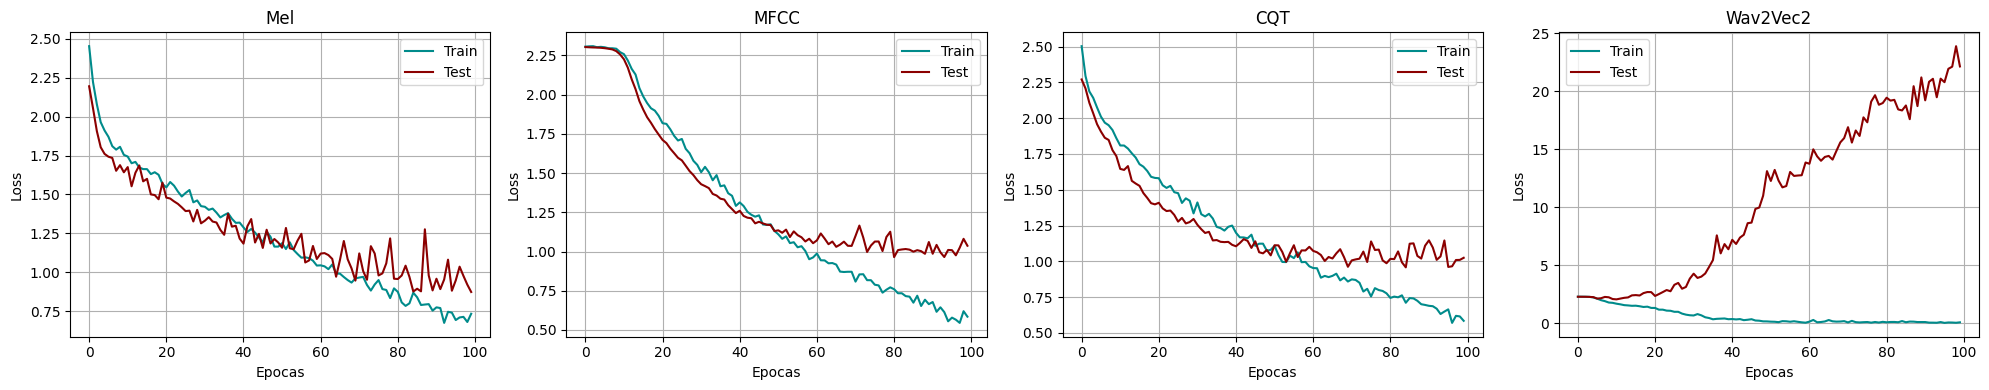

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

plot_losses(train_losses_mel, val_losses_mel, axes[0], title='Mel')
plot_losses(train_losses_mfcc, val_losses_mfcc, axes[1], title='MFCC')
plot_losses(train_losses_cqt, val_losses_cqt, axes[2], title='CQT')
plot_losses(train_losses_wav2vec2, val_losses_wav2vec2, axes[3], title='Wav2Vec2')
#for ax in axes:
#    ax.set_ylim(-0.1, 2.5)
plt.tight_layout()
plt.show()

Aumentar las epocas

Accuracy de `0.70`, `0.62`, `0.68` y `0.25` respectivamente

### Auxs

In [26]:
X_test = np.load('../Data/X_test_mel.npy') 
X_train = []
print(f"Testeo: {len(X_test)} pares")

test_dataset = Image_dataset(X_test, y_test)
test_dataset[1]

Testeo: 180 pares


{'input': tensor([[-17.9474, -13.7789, -23.3506,  ..., -20.5041, -17.5524, -21.1973],
         [-16.9803, -12.2452, -21.5641,  ..., -21.2815, -14.0695, -21.4555],
         [-17.9659, -16.9527, -22.6373,  ..., -14.2629, -12.4558, -18.5876],
         ...,
         [-72.8470, -80.0000, -80.0000,  ..., -67.5897, -67.9812, -71.3745],
         [-75.1064, -80.0000, -80.0000,  ..., -77.1519, -76.6741, -79.6736],
         [-76.0252, -80.0000, -80.0000,  ..., -80.0000, -80.0000, -80.0000]],
        device='cuda:0'),
 'target': tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], device='cuda:0'),
 'input_length': (80, 3001),
 'target_length': 10}

In [28]:
conv1 = nn.Conv1d(in_channels=80, out_channels=128, kernel_size=3, stride=1, padding=1).to(device)
conv2 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1).to(device)
conv3 = nn.Conv1d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1).to(device)
global_pool = nn.AdaptiveAvgPool1d(1).to(device)

x = test_dataset[1]['input'].unsqueeze(0)  # batch (1, 80, 3001)
print(f"Input shape: {x.shape}")

Input shape: torch.Size([1, 80, 3001])


In [29]:
y = conv1(x)
y = F.max_pool1d(y, kernel_size=3, stride=3)
y = conv2(y)
y = F.max_pool1d(y, kernel_size=3, stride=3)
y = conv3(y)
y = F.max_pool1d(y, kernel_size=3, stride=3)
y = global_pool(y)
y = y.view(y.size(0), -1)  # Flatten
print(f"Output shape: {y.shape}")

Output shape: torch.Size([1, 512])
